<a href="https://colab.research.google.com/github/celinadavis25-cell/Machine-Learning/blob/main/Housing_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CORRECTED HOUSING PREDICTIONS**

In [1]:
import pandas as pd
import numpy as np

In [2]:
housing = pd.read_csv("housing_dirty_500.csv")
housing.head()

,area,rooms,price
0,4220.0,6.0,270600.0
1,4200 sqft,3,"278,000"
2,1970.0,7.0,107900.0
3,2890.0,6.0,"₦171,000"
4,990.0,6.0,43500.0


In [3]:
housing.isnull()

,area,rooms,price
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
520,False,False,False
521,False,False,False
522,False,True,False
523,False,False,False


In [4]:
housing.isnull().sum()

,0
area,21
rooms,25
price,15


In [5]:
housing.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
520,False
521,False
522,False
523,False


In [6]:
housing.duplicated().sum()

np.int64(25)

In [7]:
housing["area"] = housing["area"].astype(str).str.replace("sqft", "", regex=False)
housing["area"] = housing["area"].str.replace(",", "", regex=False).str.strip()
housing["price"] = housing["price"].astype(str).str.replace(r"[₦$,]", "", regex=True).str.strip()

word_to_num = {"one": "1", "two": "2", "three": "3", "four": "4", "five": "5"}
housing["rooms"] = housing["rooms"].astype(str).str.strip().replace(word_to_num)
housing["rooms"] = housing["rooms"].str.replace("rooms", "", regex=False).str.strip()

In [8]:
for col in ["area", "rooms", "price"]:
    housing[col] = pd.to_numeric(housing[col], errors="coerce")

In [9]:
housing.loc[housing["area"] <= 0, "area"] = np.nan
housing.loc[housing["price"] <= 0, "price"] = np.nan

In [10]:
for col in ["area", "rooms", "price"]:
    housing[col] = housing[col].fillna(housing[col].median())

In [11]:
def cap_outliers_iqr(housing, column):
    Q1, Q3 = housing[column].quantile(0.25), housing[column].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    housing[column] = housing[column].clip(lower=lower, upper=upper)
    return housing

for col in ["area", "price"]:
    housing = cap_outliers_iqr(housing, col)

In [12]:
print("Before:", len(housing))
housing = housing.drop_duplicates()
print("After:", len(housing))

Before: 525
After: 500


In [13]:
print(housing.dtypes)
print(housing.isnull().sum())
print(housing.describe())

area     float64
rooms    float64
price    float64
dtype: object
area     0
rooms    0
price    0
dtype: int64
              area      rooms          price
count   500.000000  500.00000     500.000000
mean   2932.340000    4.51200  181612.600000
std    1297.415005    1.95384   91125.607234
min     720.000000    1.00000   15000.000000
25%    1777.500000    3.00000  104325.000000
50%    2900.000000    4.00000  182650.000000
75%    3987.500000    6.00000  256950.000000
max    7270.000000    9.00000  482950.000000


In [16]:
housing.to_csv("housing_cleaned_500.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [17]:
from google.colab import files
files.download("housing_cleaned_500.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
housing = pd.read_csv("housing_cleaned_500.csv")
housing.head()

,area,rooms,price
0,4220.0,6.0,270600.0
1,4200.0,3.0,278000.0
2,1970.0,7.0,107900.0
3,2890.0,6.0,171000.0
4,990.0,6.0,43500.0


In [19]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   area    500 non-null    float64
 1   rooms   500 non-null    float64
 2   price   500 non-null    float64
dtypes: float64(3)
memory usage: 11.8 KB


In [21]:
housing_X = housing[["area", "rooms"]]

housing_y = housing["price"]

housing_X

,area,rooms
0,4220.0,6.0
1,4200.0,3.0
2,1970.0,7.0
3,2890.0,6.0
4,990.0,6.0
...,...,...
495,2040.0,5.0
496,1230.0,6.0
497,3460.0,4.0
498,2580.0,7.0


In [23]:
from sklearn.model_selection import train_test_split

In [24]:
housing_X_train, housing_X_test, housing_y_train, housing_y_test = train_test_split(
    housing_X,
    housing_y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(housing_X_train))
print("Testing samples:", len(housing_X_test))

Training samples: 400
Testing samples: 100


In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
model = LinearRegression()

model

LinearRegression()

In [29]:
housing_model = LinearRegression()

housing_model.fit(housing_X_train, housing_y_train)



LinearRegression()

In [31]:
housing_predictions = housing_model.predict(housing_X_test)

housing_predictions

array([176454.0660835 , 221110.69735313,  72161.67789014, 258829.85563074,
        99838.03231856, 222385.03726257, 298380.00485607, 121101.35722666,
       258305.41215903, 295992.36287006, 203573.76947363, 291281.49403118,
       302534.22265667,  83317.7838159 ,  88157.48292108, 186956.89827125,
       127546.59431355, 129998.65143271, 294750.23052719, 159409.37410913,
       269985.9615565 , 287651.7197023 , 298347.7972895 ,  54003.68383921,
       118124.85663579,  72782.74406157, 212963.29958481,  60352.29822637,
        69185.17729927, 233016.69971662,  99345.79641342, 245842.75875724,
       269461.51808479, 200565.06131618, 119827.01731722, 225918.18889173,
        61723.26083553,  92311.70072168, 197652.97585845, 153391.95779424,
       109163.14729659, 261314.12031647,  88093.06778793, 179987.21771266,
        54528.12731092, 116390.48838778, 254118.98679186, 240083.00297494,
       224119.40551058, 181786.00109381,  89335.2001308 , 247149.30623326,
       240083.00297494, 1

In [32]:
housing_comparison = pd.DataFrame({
    "Actual Price": housing_y_test.values,
    "Predicted Price": housing_predictions
})

housing_comparison

,Actual Price,Predicted Price
0,182650.0,176454.066083
1,230700.0,221110.697353
2,55000.0,72161.677890
3,275800.0,258829.855631
4,86300.0,99838.032319
...,...,...
95,320500.0,303615.317167
96,59900.0,84592.123725
97,215200.0,210672.280299
98,58700.0,78639.122544


In [33]:
from sklearn.metrics import mean_squared_error

housing_mse = mean_squared_error(housing_y_test, housing_predictions)

print("Mean Squared Error:", housing_mse)

Mean Squared Error: 1069917922.951282


In [36]:
from sklearn.metrics import mean_squared_error, r2_score

housing_mse = mean_squared_error(
    housing_y_test,
    housing_predictions
)

housing_r2 = r2_score(
    housing_y_test,
    housing_predictions
)

print("Housing MSE:", housing_mse)
print("Housing R² Score:", housing_r2)

Housing MSE: 1069917922.951282
Housing R² Score: 0.8847947217296749


In [37]:
import matplotlib.pyplot as plt

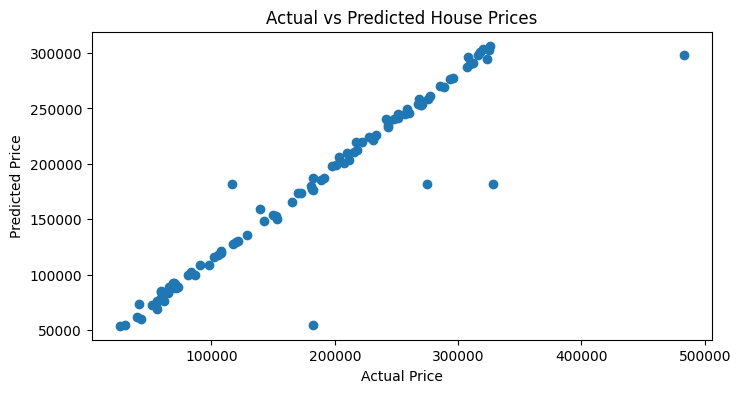

In [38]:
plt.figure(figsize=(8, 4))

plt.scatter(housing_y_test, housing_predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()


**OBSERVATIONS**


*   The predicted prices are reasonably closer to the actual prices,i can only see about five or six that are not close to the actual values.

* The R2 score is about 0.88 which is close to 1, it indicates a stronger fit.



close